# Exploratory Data Analysis & Statistical Analysis

In [8]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

import statsmodels.api as sm

In [2]:
BG_COLOR = "#23272e"  
BOX_COLOR = "#61afef"  
TEXT_COLOR = "#abb2bf"  

plt.rcParams.update(
    {
        "figure.facecolor": BG_COLOR,  
        "axes.facecolor": BG_COLOR, 
        "axes.edgecolor": "#3f444a",  
        "axes.labelcolor": TEXT_COLOR,  
        "text.color": TEXT_COLOR,  
        "xtick.color": TEXT_COLOR,
        "ytick.color": TEXT_COLOR,  
        "grid.color": "#2c313c",  
    }
)

sns.set_theme(
    style="dark",
    rc={
        "figure.facecolor": BG_COLOR,
        "axes.facecolor": BG_COLOR,
        "text.color": "#abb2bf",
        "axes.labelcolor": "#abb2bf",
        "xtick.color": "#abb2bf",
        "ytick.color": "#abb2bf",
    },
)

In [3]:
df = pd.read_parquet("../data/jev/jev_output_df.parquet")
df.info()

<class 'pandas.DataFrame'>
Index: 49812 entries, 0 to 50009
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   text                 49812 non-null  str    
 1   ragebait             49812 non-null  float64
 2   controversial        49812 non-null  float64
 3   time_sensitivity     49812 non-null  float64
 4   nicheness            49812 non-null  float64
 5   emotional_intensity  49812 non-null  float64
 6   content_type         49812 non-null  str    
 7   context_dependence   49812 non-null  float64
 8   rhetorical_target    49812 non-null  str    
 9   generalization       49812 non-null  float64
 10  sarcasm_irony        49812 non-null  float64
dtypes: float64(8), str(3)
memory usage: 14.2 MB


## Initial Pairplot

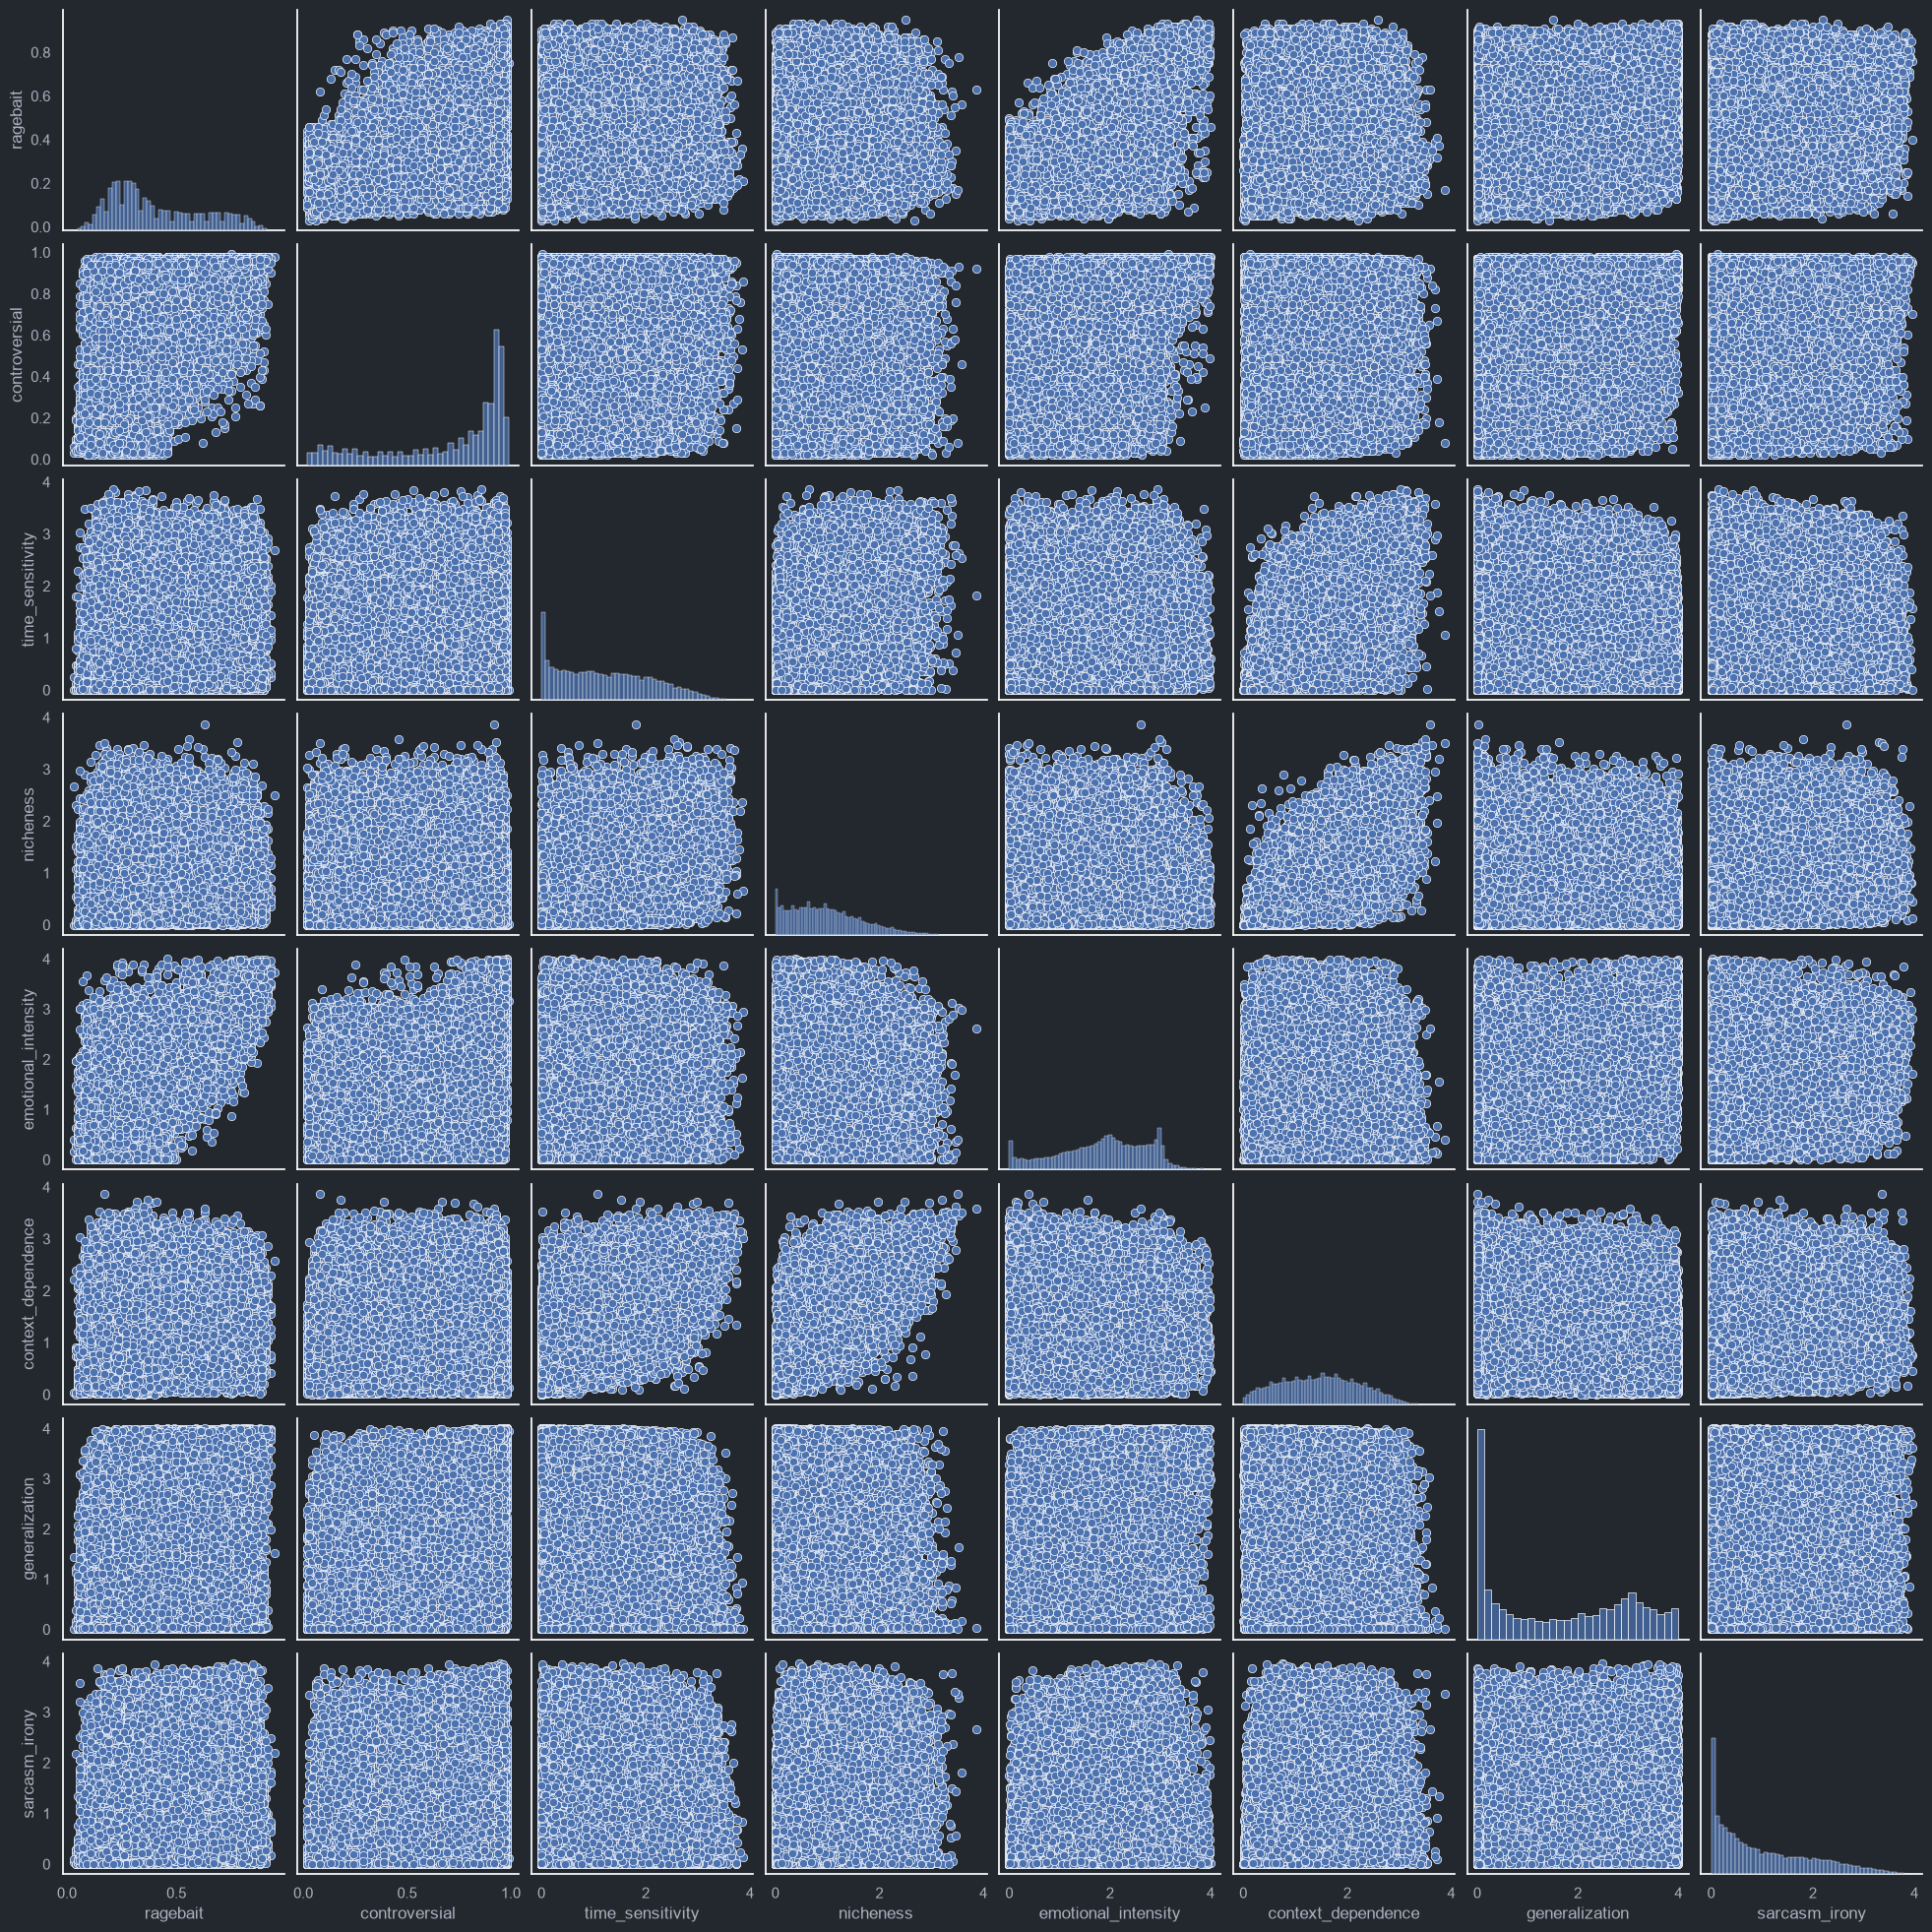

In [4]:
pairplot_df = df.drop(columns=['text', 'content_type', 'rhetorical_target'])
sns.pairplot(pairplot_df)
plt.show()

## Correlation Heatmap

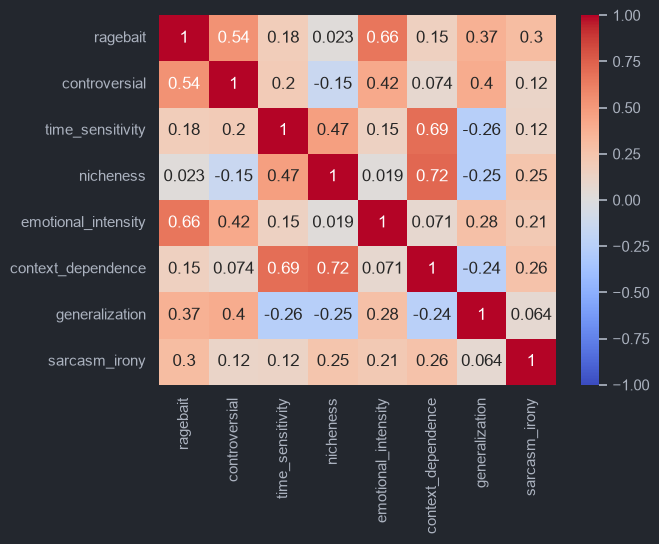

In [5]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.show()

## VIF Multicollinearity Test

In [6]:
X_const = add_constant(pairplot_df)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_const.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_const.values, i) 
    for i in range(X_const.shape[1])
]

print(vif_data)

              Variable        VIF
0                const  12.110791
1             ragebait   2.283217
2        controversial   1.730615
3     time_sensitivity   2.199302
4            nicheness   2.322276
5  emotional_intensity   1.812859
6   context_dependence   3.305086
7       generalization   1.494704
8        sarcasm_irony   1.199062


## Multiple Regression

In [15]:
df_encoded = pd.get_dummies(df, columns=['content_type', 'rhetorical_target'], drop_first=True, dtype=int)

X = df_encoded.drop(columns=['ragebait', 'text'])
y = df['ragebait']
X = sm.add_constant(X)

model_sm = sm.OLS(y, X).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:               ragebait   R-squared:                       0.611
Model:                            OLS   Adj. R-squared:                  0.611
Method:                 Least Squares   F-statistic:                     4111.
Date:                Sat, 19 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:54:12   Log-Likelihood:                 30551.
No. Observations:               49812   AIC:                        -6.106e+04
Df Residuals:                   49792   BIC:                        -6.088e+04
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
co